In [1]:
import pandas as pd 
import numpy as np
from more_itertools import unique_everseen
import spacy
from tqdm.auto import tqdm
import openai
openai.api_key_path = '/Users/spangher/.openai-isi-key.txt'

spacy_model = spacy.load('en_core_web_lg')
spacy_model.add_pipe('sentencizer')
eng_stopwords = spacy_model.Defaults.stop_words

def process_doc_list(doc_list):
    """
    Do basic text processing: remove stopwords, lemmatize, and join sentences.

    Parameters
    ----------
    doc_list : list of str, where each str is a document.
    """
    def process_doc(doc):
        output_sents = []
        sents = list(unique_everseen(doc.sents))
        for s in sents:
            s = list(filter(lambda x: str(x) not in eng_stopwords, s))
            s = list(map(lambda x: str(x.lemma_), s))
            if len(s) > 0:
                output_sents.append(' '.join(s))
        return ' '.join(output_sents)

    output_doc_list = []
    for doc in tqdm(spacy_model.pipe(
        doc_list,
        disable=["tok2vec", "parser", "ner"]
    ), total=len(doc_list)):
        output_doc_list.append(process_doc(doc))
    return output_doc_list

def get_training_weights(y_train):
    """
    Given a list of labels, return a list of weights for each label. The weights are calculated as 1 - (count of label / total count of labels).

    Parameters
    ----------
    y_train : pd.Series of 1s and 0s.
    """

    return y_train.to_frame().merge(
        y_train.value_counts().pipe(lambda s: 1 - s / s.sum()).to_frame('weight'),
        left_on='label',
        right_index=True
    ).loc[y_train.index]['weight']  

In [2]:
## Download Annotated Data 
import os 
import gdown
# output = 'cache/word-matching-annotated-meeting.xlsx'
# if not os.path.exists(output):
#     url = 'https://docs.google.com/spreadsheets/d/1Jix8N_6pCIJ3KGsQ7i86WG6SNz53TA_12yg8sjGV4M8/edit#gid=2144258436'
#     gdown.download(url, output, quiet=True)

# output = 'cache/lr-annotated-meeting.xlsx'
# if not os.path.exists(output):
#     url = 'https://docs.google.com/spreadsheets/d/1mejjGUJyikUTj7Aj1l_6jVQnmwKKwmM1dKbIvrWKbjE/edit#gid=2030813531'
#     gdown.download(url, output, quiet=True)
    

# output = 'cache/round-3-annotated-meeting-summary-text.xlsx'
# if not os.path.exists(output):
#     url = 'https://docs.google.com/spreadsheets/d/1QIonNNvlCsSrQlQBUd26rrRYYsTa4sCCrQWqp3yC6bI/edit#gid=1672331305'
#     gdown.download(url, output, quiet=True)

## read and concat
word_matching_annot_df = (
    pd.read_excel('cache/word-matching-annotated-meeting.xlsx', index_col=0)
    .loc[lambda df: df['Label'].notnull()]
)

lr_annot_df = (
    pd.read_excel('cache/lr-annotated-meeting.xlsx', index_col=0)
)

word_matching_annot_df = word_matching_annot_df.rename(columns={
    'Meeting': 'meeting',
    'Meeting Date': 'meeting_date',
    'Label': 'label',
    'Needed bottom text': 'needed_full_text'
}).assign(method='word_matching')

lr_annot_df= lr_annot_df.rename(columns={
    'Discusses a a meeting (1=yes, 0=No)': 'label',
    'If so, what is the meeting committee': 'meeting', 
    'If so, what is the meeting date': 'meeting_date',
    'Article was published on': 'article_publish_date',
    'Article was published on:': 'article_publish_date',
    'Was the bottom text necessary?': 'needed_full_text',
    'Needed bottom text': 'needed_full_text',
}).loc[lambda df: df['label'].notnull()].assign(method='lr')

round_3_annot_df = (
    pd.read_excel('cache/round-3-annotated-meeting-summary-text.xlsx', index_col=0).assign(method='round_3')
        .loc[lambda df: df['label'].notnull()]
        .rename(columns={'summary_text': 'article'})
)

keyword_candidates = [
    'San Francisco supervisors',
    'city supervisors',
    'Board of Supervisors'
]

In [3]:
first_round_annotation_df = (
    pd.read_csv('cache/2023-04-19__first-round-annotated-sentence-level-training-data-processed.csv')
    .rename(columns={'text': 'article', 'City Council Meeting Date': 'meeting_date'})
    .assign(method='full_label_first_round')
)

second_round_annotation_df = (
    pd.read_csv('cache/2023-04-19__second-round-annotated-sentences-processed.csv')
    .rename(columns={'text': 'article',})
    .loc[lambda df: df['article'].fillna('').str.contains('|'.join(keyword_candidates), regex=True, case=False)]
    .assign(method='second_round')
)

full_deep_annotation_df = pd.concat([
    lr_annot_df, 
    word_matching_annot_df,
    first_round_annotation_df,
    second_round_annotation_df,
    round_3_annot_df
]).assign(label=lambda df: df['label'].pipe(lambda s: s > 0).astype(int))

## Write 
annot_path = 'cache/2023-04-19__full-deep-annotation-df.csv'
if not os.path.exists(annot_path):
    full_deep_annotation_df.to_csv(annot_path)

# Data

In [4]:
## City Council Meeting Data
full_meeting_row_df = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')
full_meeting_row_df = full_meeting_row_df.assign(text=lambda df: df['Name'] + '. ' + df['Title']).drop(columns=['Name', 'Title'])
full_meeting_row_df['date'] = pd.to_datetime(full_meeting_row_df['date'])
# full_meeting_row_df['processed_text'] = process_doc_list(full_meeting_row_df['text'].fillna('').tolist())

full_deep_annotation_df = pd.read_csv('cache/2023-04-19__full-deep-annotation-df.csv', index_col=0)

In [17]:
## build classifier to determine whether an article is about a city council meeting or not 
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split

lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegressionCV(cv=10, max_iter=2000))
])
train_df, test_df = train_test_split(full_deep_annotation_df, test_size=.04)
weights = get_training_weights(train_df['label'].reset_index(drop=True))
lr_pipe.fit(train_df['article'], train_df['label'], lr__sample_weight=weights)
test_df['proba'] = lr_pipe.predict_proba(test_df['article'])[:, 1]
from sklearn.metrics import classification_report
print(classification_report(test_df['label'], test_df.pipe(lambda df: df['proba'] >= .5)))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.85      1.00      0.92        22

    accuracy                           0.86        28
   macro avg       0.92      0.67      0.71        28
weighted avg       0.88      0.86      0.83        28



In [18]:
all_candidate_articles = pd.read_json('cache/2023-04-19__candidate-articles-filtered-by-keyword.jsonl', lines=True)

In [19]:
all_candidate_articles['preds'] = lr_pipe.predict(all_candidate_articles['summary_text'])

In [21]:
all_candidate_articles.loc[lambda df: df['preds'] == 1].head()

,article_url,article_text,article_publish_date,article_authors,article_top_image,article_video,article_scrape_timestamp,source,homepage_key,article_wayback_timestamp,all_article_wayback_timestamps,parsed_article_url,url_section,sentences,summary_text,preds
0,"com,sfchronicle)/bayarea/article/com,sfchronic...",Contra Costa County on Tuesday approved fines ...,2020-07-28 22:47:05+00:00,"[Catherine Ho, Heather Knight, Annie Vainshtei...",https://s.hdnux.com/photos/01/12/43/52/1954474...,[],2.023013e+13,common_crawl,NaN,NaN,None,/bayarea/article/100-for-not-wearing-a-mask-co...,bayarea,[Contra Costa County on Tuesday approved fines...,The county's board of supervisors passed an ur...,1
1,"com,sfchronicle)/bayarea/article/com,sfchronic...",This is a carousel. Use Next and Previous butt...,2021-07-22 03:05:41+00:00,"[Mallory Moench, Jessica Flores, Kurtis Alexan...",https://s.hdnux.com/photos/01/21/10/35/2126830...,[],2.023021e+13,common_crawl,NaN,NaN,None,/bayarea/article/20-000-trash-cans-no-kidding-...,bayarea,[San Francisco elected officials struggling to...,Addressing the problem requires a good trash c...,1
2,"com,sfchronicle)/bayarea/article/com,sfchronic...",This is a carousel. Use Next and Previous butt...,2018-05-10 13:00:00+00:00,"[Dominic Fracassa, J.K. Dineen, Chase Difelici...",https://s.hdnux.com/photos/73/17/73/15531739/1...,[],2.023020e+13,common_crawl,NaN,NaN,None,/bayarea/article/29-million-increase-for-san-f...,bayarea,[San Francisco Mayor Mark Farrell will propose...,He said spending on homeless programs would be...,1
8,"com,sfchronicle)/bayarea/article/com,sfchronic...",This is a carousel. Use Next and Previous butt...,2022-01-13 01:04:31+00:00,"[Megan Cassidy, Kellie Hwang, Adriana Rezal, G...",https://s.hdnux.com/photos/01/23/45/56/2191247...,[],2.023013e+13,common_crawl,NaN,NaN,None,/bayarea/article/a-month-after-s-f-mayor-breed...,bayarea,[Nearly a month after Mayor London Breed vowed...,"Breed's Tenderloin emergency declaration, whic...",1
9,"com,sfchronicle)/bayarea/article/com,sfchronic...",Anybody who’s sat through a Board of Superviso...,2015-04-22 23:21:28+00:00,"[Heather Knight, Michael Cabanatuan, Sriharsha...",https://s.hdnux.com/photos/32/45/15/6968176/8/...,[],2.023013e+13,common_crawl,NaN,NaN,None,/bayarea/article/a-new-agenda-for-the-supes-an...,bayarea,[Anybody who's sat through a Board of Supervis...,Anybody who's sat through a Board of Superviso...,1


## Extract Information from News Articles that can help us locate the right city council meetings

In [2]:
import re 
from datetime import datetime
month_2_num__mapper = {
    'january': 1,
    'february': 2,
    'march': 3,
    'april': 4,
    'may': 5,
    'june': 6,
    'july': 7,
    'august': 8,
    'september': 9,
    'october': 10,
    'november': 11,
    'december': 12
}
num2month__mapper = {v: k.title() for k, v in month_2_num__mapper.items()}

day_of_week_mapper = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

def make_council_meeting_identification_prompt(articles):
    """Given a list of articles, return a prompt that asks the annotator to identify whether the article is about a city council meeting or not.
    
    Args:
        articles (list): list of articles, as strings, or single string.
    """
    if isinstance(articles, str):
        articles = [articles]

    prompt_inputs = []
    batch_size=len(articles)
    for idx, article in enumerate(articles):
        article = article.replace('\n\n', ' ')
        prompt_input = f"Article {idx + 1}: {article}" if batch_size > 1 else f"Article: {article}"
        prompt_inputs.append(prompt_input)
    prompt_inputs = '\n'.join(prompt_inputs)

    return f'''You are a journalist in San Francisco Bay Area who covers local city council meetings and events. I'm going to show you some articles and you'll tell me what meeting happened. Possible options include but are not limited to: "San Francisco Board of Supervisors", "Alameda County Board of Supervisors", "Oakland City Council", "San Francisco School Board", "Voter Proposition", "I can't tell", "No Meeting".

    Here are examples:

    Example 1: He followed the city's transit corridor plan -- approved by nearly 70% of voters -- and spent $3 million on the approval process, repeatedly altering the project at 601-611 El Camino Real at the behest of residents and city staff. But none of that mattered July 10 when, after a six-hour hearing, a no vote by a single San Bruno council member killed the Mills Park Plaza development, a project that supporters argue would have revived 5 acres of land near BART, Caltrain and the city's downtown.
    Meeting 1: San Bruno City Council

    Example 2: During a school board committee meeting Tuesday night, district officials said they believed that the vast majority of the students lacking a class or two would still graduate on time through after-school, evening or online classes available at high schools across the city. One out of 3 seniors in San Francisco's class of 2014 - nearly 1,300 students - is in danger of not graduating.
    Meeting 2: San Francisco School Board

    Example 3: Contra Costa County on Tuesday approved fines for individuals and businesses that violate coronavirus health orders, including not wearing a mask. The county's board of supervisors passed an urgency ordinance establishing fines for individuals starting at $100 for the first violation, $200 for the second and $500 for each additional violation within one year of the initial violation.
    Meeting 3: Contra Costa County Board of Supervisors

    Ok, let's get started. Here {'are' if batch_size > 1 else 'is'} {batch_size} article{'s' if batch_size > 1 else ''}. What {batch_size} meeting{'s' if batch_size > 1 else ''} {'are' if batch_size > 1 else 'is'} being referenced:

    {prompt_inputs}
    '''


def parse_date_from_gpt3(y_pred_date_i):
    _, year, month, day = y_pred_date_i.strip().split('\n')
    year = year.replace('Year: ', '').strip()
    year = int(year)
    ## 
    month = month.strip().replace('Month: ', '')
    if month.isdigit():
        month = int(month)
    else:
        month = month_2_num__mapper.get(month.lower(), 1)
    ## 
    day = day.strip().replace('Day: ', '')    
    day = re.search('\d+', day)
    if day is not None:
        day = day.group(0)
    else:
        day = 1
    
    return pd.to_datetime(f'{year}-{month}-{day}').date()


def number_to_ordinal(num_input):
    """Convert a decimal number to it's ordinal representation.
    ex. number_to_ordinal(1) -> 1st, number_to_ordinal(2) -> 2nd, number_to_ordinal(3) -> 3rd, number_to_ordinal(4) -> 4th, etc.
    """
    num_input = int(num_input)
    if num_input % 100 in [11, 12, 13]:
        return f'{num_input}th'
    else:
        return f'{num_input}{["th", "st", "nd", "rd", "th", "th", "th", "th", "th", "th"][num_input % 10]}'


def make_council_meeting_date_prompt(article_text, date_input, include_day_of_week=False):
    def format_article_publish_date_prompt(date_input, include_day_of_week=include_day_of_week):
        date_str = date_input.strftime('%Y/%m/%d')
        if include_day_of_week:
            day_of_week = day_of_week_mapper[date_input.weekday()]
            month_name = num2month__mapper[date_input.month]
            day_name = number_to_ordinal(date_input.day)
            return f'{day_of_week}, {month_name} {day_name}, {date_input.year} ({date_str})'
        else:
            return date_str

    prompt_text = f'''You are a journalist in San Francisco Bay Area who covers local city council meetings and events. 
        I'm going to show you some articles and you'll tell me the year, month and date that the meeting mentioned took place on. 
        Look for clues relative to the article publish date I will provide. If you can only determine the year and month, that's OK. 
        Ignore irrelevant dates.

        Here are examples:

        (Example 1)
            The article was published on: {format_article_publish_date_prompt(datetime(2013, 10, 3))}
            Article Text: "During a school board committee meeting Tuesday night, district officials said they believed that the vast majority of the students lacking a class or two would still graduate on time through after-school, evening or online classes available at high schools across the city.\n\nOne out of 3 seniors in San Francisco's class of 2014 - nearly 1,300 students - is in danger of not graduating. While more than 900 of those off track are missing only a couple of classes and should be able to make them up in time, district officials are considering what else they can do for the lagging students and whether they should back off tougher graduation requirements kicking in this year."
        Answer:
            Day-of-week: Tuesday
            Year: 2013
            Month: 10
            Day: 1
        
        (Example 2)        
            The article was published on: {format_article_publish_date_prompt(datetime(2018, 9, 27))}
            Article Text: "In May 2016, the Board of Supervisors voted 10-1 to approve a $260 million emergency bailout after massive cost overruns -- blamed largely on poor management by TJPA officials -- threatened to halt construction. Frustrated San Francisco officials said they want answers about why cracks have been found in two beams at the new Transbay Transit Center -- the latest major piece of infrastructure to fall victim to serious structural problems."
        Answer:
            Day-of-week: Cannot determine
            Year: 2016
            Month: May
            Day: Cannot determine

        (Example 3)
            The article was published on: {format_article_publish_date_prompt(datetime(2022, 1, 13))}
            Article Text: "Breed's Tenderloin emergency declaration, which was approved by the Board of Supervisors in late December, green-lighted a service center where outreach workers can refer people on the streets for housing and treatment. Nearly a month after Mayor London Breed vowed a police crackdown on drug dealing, open-air drug use and other crimes plaguing the Tenderloin, arrests in the neighborhood have remained flat and the Police Department has not sent more officers to patrol the area."
        Answer:
            Day-of-week: Cannot determine
            Year: 2021
            Month: December
            Day: Cannot determine

        Ok, let's get started. Here is 1 article. What year, month and day did the meeting mentioned in the article occur? 
        Look for clues relative to the article publish date I will provide. If you can only determine the year and month, that's OK. Ignore dates of events besides the meeting.

        (Article 1)
        The article was published on: {format_article_publish_date_prompt(date_input)}
        Article Text: {article_text}
        Answer:
    '''
    return prompt_text

In [345]:
full_deep_annotation_df['meeting'] = (
    full_deep_annotation_df['meeting']
        .str.replace('SFBOS', 'San Francisco Board of Supervisors')
        .str.replace('SFUSD', 'San Francisco School Board')
        .str.replace('BOS', 'Board of Supervisors')
        .str.replace('SF', 'San Francisco')
 )

In [377]:
(full_deep_annotation_df
 .loc[lambda df: df['meeting'].notnull()]
 ['meeting']
 .str.split(', ', expand=True)
 .unstack()
 .dropna()
 .value_counts()
 .head(4)
)

San Francisco Board of Supervisors           64
Bay Area Rapid Transit Board of Directors    15
Alameda County Board of Supervisors           9
Oakland City Council                          5
dtype: int64

In [151]:
articles = (
    full_deep_annotation_df
        .loc[lambda df: df['meeting'].notnull()]
        .loc[lambda df: df['label'] == 1]
        [['article', 'meeting']]
)

In [331]:
batch_size = 1
s = list(range(0, len(articles), batch_size))
y_true = []
y_preds = []

# model = "text-davinci-003"
model = "gpt-3.5-turbo"

for s_i in tqdm(s):
    batch_articles = articles['article'].iloc[s_i:s_i+batch_size]
    meetings = articles['meeting'].iloc[s_i:s_i+batch_size].tolist()
    y_true.append(meetings)
    prompt = make_council_meeting_identification_prompt(batch_articles)
    if model == 'text-davinci-003':
        completion = openai.Completion.create(
            model="text-davinci-003",
            prompt=prompt,
            max_tokens=50,
            temperature=.1
        )
        y_pred = completion.to_dict_recursive()['choices'][0]['text'].strip()
    else:
        completion = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        y_pred = completion.to_dict_recursive()['choices'][0]['message']['content'].strip()

    y_preds.append(y_pred)

  0%|          | 0/144 [00:00<?, ?it/s]

In [342]:
y_true_df = pd.concat([
    pd.Series(y_true)
        .str.get(0)
        .apply(lambda x: 'San Francisco Board of Supervisors' if 'San Francisco Board of Supervisors' in x else x)
        .to_frame('y_true'),
    pd.Series(y_preds)
        .str.replace('Meeting: ', '')
        .str.strip()
        .str.replace('BART', 'Bay Area Rapid Transit')
        .to_frame('y_pred')
], axis=1)

In [358]:
# ChatGPT
(y_true_df
 .assign(y_true=lambda df: df['y_true']
    .str.replace('SFBOS', 'San Francisco Board of Supervisors')
    .str.replace('SFUSD', 'San Francisco School Board')
    .str.replace('BOS', 'Board of Supervisors')
    .str.replace('SF', 'San Francisco')
    .apply(lambda x: 'San Francisco Board of Supervisors' if 'San Francisco Board of Supervisors' in x else x)
 )
  .assign(y_pred=lambda df: df['y_pred'].str.replace('.', '', regex=False))  
 ).pipe(lambda df: df['y_true'] == df['y_pred']).mean()

0.75

In [540]:
# Text Davinci
y_true_df.pipe(lambda df: df['y_true'] == df['y_pred']).mean()

0.7746478873239436

In [541]:
y_true_df.loc[lambda df: df['y_true'] != df['y_pred']]

,y_true,y_pred
0,San Bruno,San Bruno City Council
2,Contra Costa County,Contra Costa County Board of Supervisors
3,Federal Court,No Meeting
5,Spreckels Union School District,Spreckels Union School District Board
10,Santa Clara Stadium Authority Board,Santa Clara City Council
12,San Francisco Superior Court,No Meeting
15,Peralta Board,Oakland City Council
22,Alameda County Board of Supervisors,Oakland School Board
24,Alameda School District,Alameda School Board
25,Federal court,San Francisco School Board


In [36]:
dates_to_test_df = (
    full_deep_annotation_df
        .assign(article_publish_date=lambda df: pd.to_datetime(df['article_publish_date']).dt.date)
        .assign(meeting_date=lambda df: pd.to_datetime(df['meeting_date'], errors='coerce').dt.date)
        .loc[lambda df: df['meeting_date'].notnull() & df['article_publish_date'].notnull()]
        .loc[lambda df: df['meeting_date'].apply(lambda x: type(x) != float)]
        [['article', 'meeting_date', 'article_publish_date']]
)

In [105]:
def collect_dates_gpt(dates_to_test_df, include_day_of_week=False):
    y_true_date = []
    y_pred_date = []
    for _, t in tqdm(dates_to_test_df.iterrows(), total=len(dates_to_test_df)):
        prompt = make_council_meeting_date_prompt(t['article'], t['article_publish_date'], include_day_of_week=include_day_of_week)
        completion = openai.Completion.create(
            model="text-davinci-003",
            prompt=prompt,
            max_tokens=50,
            temperature=.1
        )
        y_pred_date.append(completion.to_dict_recursive()['choices'][0]['text'])
        y_true_date.append(t['meeting_date'])
    y_pred_date_parsed = list(map(parse_date_from_gpt3, y_pred_date))
    y_pred_date_df = pd.concat([
        pd.Series(y_pred_date).to_frame('y_pred_date_text'),
        pd.Series(y_pred_date_parsed).to_frame('y_pred_date_parsed'),
        pd.Series(y_true_date).to_frame('y_true_date')
    ], axis=1)
    y_pred_date_df.index = dates_to_test_df.index
    y_pred_date_df = pd.concat([
        dates_to_test_df[['article', 'article_publish_date']],
        y_pred_date_df
    ], axis=1)

    return y_pred_date_df

In [ ]:
y_pred_date_df = collect_dates_gpt(dates_to_test_df, include_day_of_week=False)

In [108]:
y_pred_date_df_with_date = collect_dates_gpt(dates_to_test_df, include_day_of_week=True)

  0%|          | 0/117 [00:00<?, ?it/s]

In [111]:
(y_pred_date_df_with_date
 .pipe(lambda df: df['y_pred_date_parsed'] == df['y_true_date'])
 .mean()
)

0.5982905982905983

In [145]:
month_window = 1
(y_pred_date_df_with_date
 .assign(y_pred_date=lambda df: df['y_pred_date_parsed'].apply(lambda x: (x.year, x.month)))
 .assign(y_true_date=lambda df: df['y_true_date'].apply(lambda x: (x.year, x.month)))
 .pipe(lambda df: df.apply(lambda x: x['y_true_date'] in list(map(lambda y: (x['y_pred_date'][0], x['y_pred_date'][1] + y), range(-month_window, month_window + 1))) , axis=1))
 .mean()
)

0.7264957264957265

In [146]:
(y_pred_date_df_with_date
 .assign(y_pred_date=lambda df: df['y_pred_date_parsed'].apply(lambda x: (x.year)))
 .assign(y_true_date=lambda df: df['y_true_date'].apply(lambda x: (x.year)))
 .pipe(lambda df: df['y_pred_date'] == df['y_true_date'])
 .mean()
)

0.7521367521367521

In [148]:
month_window = 1
(
    y_pred_date_df_with_date
        .assign(y_pred_date=lambda df: df['article_publish_date'].apply(lambda x: (x.year, x.month)))
        .assign(y_true_date=lambda df: df['y_true_date'].apply(lambda x: (x.year, x.month)))
        .pipe(lambda df: df.apply(lambda x: x['y_true_date'] in list(map(lambda y: (x['y_pred_date'][0], x['y_pred_date'][1] + y), range(-month_window, month_window + 1))) , axis=1))
        .mean()
)

0.905982905982906

# Test the matching

In [ ]:
## Todo for next week:
## ------------------------------------------------------------------------------------------------------------------------
## 1. Use GPT results (?) to determine SFBOS meetings across the candidate articles. 
## 2. Match the article snippets to the meeting minutes and see if you can find the ones with the top score.
##          a. word overlap
##          b. Ask GPT
##          c. Maybe train a different DPR-style, or SentenceBERT-style model? With triplet loss?
## 3. First, use a window around the article publish date as a good starting point.
## 4. Then, try building a GPT3 plugin to give it a better date-cognition, and then train a date model.

In [168]:
first_round_annotation_df['meeting_date'].pipe(pd.to_datetime)
first_round_annotation_df['News Article Date'].pipe(pd.to_datetime, errors='coerce').isnull().value_counts()

False    69
True     10
Name: News Article Date, dtype: int64

In [24]:
first_round_annotation_df['News Article Date'] = (
    first_round_annotation_df['News Article Date']
        .str.split('(')
        .str.get(0)
        .pipe(pd.to_datetime, errors='coerce')
)

In [25]:
sfbos_first_round_annotation_df = (
    first_round_annotation_df.loc[lambda df: df['City Council Meeting Minute URL'].str.contains('sfbos') == True]
)

In [26]:
sfbos_first_round_annotation_df['meeting_id'] = sfbos_first_round_annotation_df['Page/paragraph'].str.split(' ').str.get(-1)
sfbos_first_round_annotation_df = sfbos_first_round_annotation_df.loc[lambda df: df['meeting_id'].str.len() == 6]

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_21351/2435179354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sfbos_first_round_annotation_df['meeting_id'] = sfbos_first_round_annotation_df['Page/paragraph'].str.split(' ').str.get(-1)


In [211]:
from datetime import timedelta
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_all = TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english', ngram_range=(1, 3))
tfidf_all.fit(pd.concat([ all_candidate_articles['article_text'].dropna(), full_meeting_row_df['text'].dropna() ], ))

In [443]:
def get_similar_meetings(article_text, article_date, meeting_df, k=4, window=30, tfidf=tfidf_all):
    """Gets the top-k most similar meetings to a given article text, within a date-range.
    
    Parameters
    ----------
    article_text : str
        The text of the article to match.
    article_date : datetime
        The date of the article to match.
    meeting_df : pd.DataFrame
        The dataframe of meetings to match against. Must have the following columns: `text`, `date`, `committee`, `File #`.
    k : int
        The number of meetings to return.
    window : int
        The number of days before and after the article date to consider.
    tfidf : sklearn.feature_extraction.text.TfidfVectorizer
        The TF-IDF vectorizer to use.
    """
    
    query_vec = tfidf.transform([article_text])
    date_limited_meeting_df = (
        meeting_df
            .drop_duplicates('File #')
            .loc[lambda df: df['date'].dt.date > article_date.date() - timedelta(days=window)]
            .loc[lambda df: df['date'].dt.date <= article_date.date() + timedelta(days=window)]
            .loc[lambda df: df['committee'] == 'Board of Supervisors']
    )
    if len(date_limited_meeting_df) == 0:
        return None 

    key_vecs = date_limited_meeting_df['text'].pipe(tfidf_all.transform)
    sims = cosine_similarity(query_vec, key_vecs).flatten()
    date_limited_meeting_df['sims'] = sims
    return date_limited_meeting_df.sort_values('sims', ascending=False).iloc[:k]

In [367]:
# ideal 
k = 4
window = 30

retrieval_acc = []

for window in [15, 30, 45, 60]:
    for k in tqdm(range(20)):
        for _,  (news_article_date, article, meeting_id) in (
            sfbos_first_round_annotation_df[['News Article Date', 'article', 'meeting_id']].iterrows()
        ):  
            top_meetings = get_similar_meetings(article, news_article_date, full_meeting_row_df, k=k, window=window)
            acc = meeting_id in top_meetings['File #'].astype(int).astype(str).tolist()
            
            retrieval_acc.append({
                'acc': acc,
                'k': k,
                'window': window,
            })

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [371]:
pd.DataFrame(retrieval_acc).groupby(['k', 'window'])['acc'].mean().max()

0.8305084745762712

<AxesSubplot:xlabel='k', ylabel='acc'>

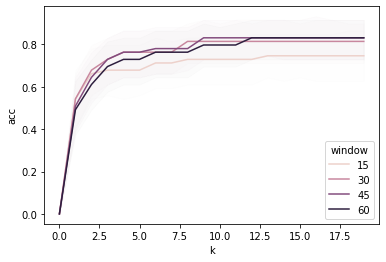

In [375]:
import seaborn as sns
sns.lineplot(data=pd.DataFrame(retrieval_acc), x='k', y='acc', hue='window', err_kws={'alpha': .01})

In [381]:
pd.DataFrame(retrieval_acc).groupby(['window', 'k'])['acc'].mean().unstack().iloc[:, :10]

k,0,1,2,3,4,5,6,7,8,9
window,,,,,,,,,,
15,0.0,0.542373,0.661017,0.677966,0.677966,0.677966,0.711864,0.711864,0.728814,0.728814
30,0.0,0.542373,0.677966,0.728814,0.762712,0.762712,0.762712,0.762712,0.813559,0.813559
45,0.0,0.508475,0.644068,0.728814,0.762712,0.762712,0.779661,0.779661,0.779661,0.830508
60,0.0,0.491525,0.610169,0.694915,0.728814,0.728814,0.762712,0.762712,0.762712,0.796610


# Do the Matching

In [287]:
all_candidate_articles['summary_text'].iloc[0]

"The county's board of supervisors passed an urgency ordinance establishing fines for individuals starting at $100 for the first violation, $200 for the second and $500 for each additional violation within one year of the initial violation.\n\nContra Costa County on Tuesday approved fines for individuals and businesses that violate coronavirus health orders, including not wearing a mask. The county's board of supervisors passed an urgency ordinance establishing fines for individuals starting at $100 for the first violation, $200 for the second and $500 for each additional violation within one year of the initial violation. Fines for businesses will start at $250 for the first violation, $500 for the second and $1,000 for each additional violation within one year of the initial violation."

In [ ]:
all_meeting_preds = []
import time 
for _ in range(10):
    try:
        for text in tqdm(
            all_candidate_articles['summary_text'].iloc[len(all_meeting_preds):], 
            total=len(all_candidate_articles) - len(all_meeting_preds)
        ):
            prompt = make_council_meeting_identification_prompt(text)
            completion = openai.Completion.create(
                model="text-davinci-003",
                prompt=prompt,
                max_tokens=50,
                temperature=.1
            )
            y_pred = completion.to_dict_recursive()['choices'][0]['text'].strip()
            all_meeting_preds.append(y_pred)
    except:
        time.sleep(10)    

In [301]:
pd.Series(all_meeting_preds).to_csv('cache/2023-04-28__gpt3-meeting-preds.csv', index=False)

In [302]:
len(all_meeting_preds)

6415

In [305]:
all_candidate_articles['meeting_pred'] = all_meeting_preds

In [386]:
all_candidate_articles['meeting_pred'].value_counts()

Meeting: San Francisco Board of Supervisors                                                                                                         4989
Meeting: No Meeting                                                                                                                                  283
Meeting: Alameda County Board of Supervisors                                                                                                         256
Meeting: Santa Clara County Board of Supervisors                                                                                                     104
Meeting: Oakland City Council                                                                                                                         90
                                                                                                                                                    ... 
Meeting: Bay Area Toll Authority Oversight Committee                              

In [405]:
d = all_candidate_articles['article_publish_date'].pipe(pd.to_datetime).iloc[0]

In [414]:
d.date() - timedelta(days=30)

datetime.date(2020, 6, 28)

In [403]:
(all_candidate_articles
        .loc[lambda df: df['meeting_pred'] == 'Meeting: San Francisco Board of Supervisors']
        .assign(article_publish_date=lambda df: df['article_publish_date'].pipe(pd.to_datetime))
        ['article_publish_date'].iloc[0]
)

datetime.date(2021, 7, 22)

In [473]:
(all_candidate_articles
        .loc[lambda df: df['meeting_pred'] == 'Meeting: San Francisco Board of Supervisors']
        ['summary_text']
        .pipe(lambda s: print(s.iloc[10]))
)

Under the final settlement approved by the Board of Supervisors in January 2020, the school agreed to pay $20.4 million in fines and fees, and another $37.6 million for the city to build affordable housing units the Academy of Art had removed from the market, convert nine school properties back to lawful use, and restore 12 historic buildings.

The Academy of Art University in San Francisco has settled a 12-year-old federal fraud lawsuit with four former recruiters whose case had threatened to cripple the huge for-profit school if it had lost in court. The amount of the settlement was not immediately disclosed. Announced Thursday in the U.S. District Court in Oakland, the settlement is the final chapter in a lawsuit the Academy of Art tried to get thrown out for more than a decade, even asking the U.S. Supreme Court to weigh in in 2019.


In [445]:
all_article_meeting_matched_dfs = []
for _, (article_url, article_text, article_publish_date, summary_text) in tqdm(
    all_candidate_articles
        .loc[lambda df: df['meeting_pred'] == 'Meeting: San Francisco Board of Supervisors']
        .assign(article_publish_date=lambda df: df['article_publish_date'].pipe(pd.to_datetime))
        [['article_url', 'article_text', 'article_publish_date', 'summary_text']]
        .pipe(lambda df: tqdm(df.iterrows(), total=len(df))
):
    similar_meetings = get_similar_meetings(summary_text, article_publish_date, full_meeting_row_df)
    if similar_meetings is None: continue
    
    similar_meetings = similar_meetings.copy()
    similar_meetings['article_url'] = article_url
    similar_meetings['article_publish_date'] = article_publish_date
    similar_meetings['summary_text'] = summary_text
    similar_meetings['article_text'] = article_text
    all_article_meeting_matched_dfs.append(similar_meetings)    

  0%|          | 0/6415 [00:00<?, ?it/s]

In [455]:
(pd.concat(all_article_meeting_matched_dfs).drop(columns='article_text')
 .head(1000)
 .to_csv('cache/2023-04-28__top-4-meetings-matched-to-articles.csv', index=False)
)

In [474]:
pd.concat(all_article_meeting_matched_dfs).loc[lambda df: df['sims'] > .1]['article_url'].nunique()

2367

# Evaluate performance

In [3]:
evaluate_link = 'https://docs.google.com/spreadsheets/d/17Ge2MN6onqiKn6L2Yx9VOPhK7oXLE2bBtNci8v4731g/edit?usp=sharing'
output = 'cache/full-automated-meeting-article-matching__annotated.xlsx'
gdown.download(evaluate_link, output, quiet=True)

In [4]:
end_to_end_annotated_df = pd.read_excel(output)

In [5]:
end_to_end_annotated_df = end_to_end_annotated_df.loc[lambda df: df['Label'].notnull()]

In [6]:
end_to_end_annotated_df.groupby('article_url')['Label'].apply(lambda s: s.sum()).mean()

0.2857142857142857

In [7]:
end_to_end_annotated_df.loc[lambda df: df['Label'] == 1]['similarity']

0      0.130043
12     0.164014
16     0.113584
28     0.143740
29     0.132186
30     0.111635
31     0.111348
44     0.150745
45     0.103451
56     0.184100
68     0.157256
124    0.073393
128    0.098551
136    0.054609
144    0.193346
145    0.170285
146    0.169481
147    0.094975
149    0.093161
204    0.138909
217    0.270226
218    0.263459
257    0.098534
272    0.272174
276    0.134703
312    0.070059
344    0.397087
388    0.125292
Name: similarity, dtype: float64

In [498]:
(end_to_end_annotated_df
 .loc[lambda df: df['Label'] == 1][['proposal text', 'article summary']]
).iloc[0].values

array(["Release of Reserved Funds - Public Works - Trash Can Design and Deployment - $427,500. Motion authorizing the release of reserved funds in the amount of $427,500 placed on Board of Supervisors' reserve by Ordinance No. 165-20, to fund the new trash can design and deployment.",
       "Addressing the problem requires a good trash can, but on Wednesday, a committee of the Board of Supervisors wrestled with how to replace many substandard bins when it learned that a batch of new, custom-made design prototypes will cost $12,000 to $20,000 apiece.\n\nSan Francisco elected officials struggling to deal with complaints about garbage piling up on the city's sidewalks and streets have been waiting three years for a solution -- only to get sticker shock when they heard the details this week. Addressing the problem requires a good trash can, but on Wednesday, a committee of the Board of Supervisors wrestled with how to replace many substandard bins when it learned that a batch of new, cust

In [506]:
(end_to_end_annotated_df
 .loc[lambda df: df['Label'] == 0]
 .sort_values('similarity', ascending=False)
#  [['proposal text', 'article summary']]
 .iloc[2]
 .to_dict()
)

{'city': 'San Francisco',
 'date': Timestamp('2019-06-04 00:00:00'),
 'committee': 'Board of Supervisors',
 'File #': 190487.0,
 'proposal text': 'Participation Agreement - California Mental Health Services Authority - Tech Suite Mental Health Services Act Innovation Program - Not to Exceed $1,197,821. Resolution authorizing the Director of Health to enter into a participation agreement between San Francisco Department of Public Health Behavioral Health Services and the California Mental Health Services Authority, for the Tech Suite Mental Health Services Act Innovation Program for the development of technology-based mental health solutions intended to increase access to mental health support to underserved communities, for an amount not to exceed $1,197,821 for the term of June 1, 2019, through June 30, 2022.',
 'similarity': 0.292954818481659,
 'article_url': 'com,sfchronicle)/bayarea/article/com,sfchronicle)/bayarea/article/free-mental-health-care-for-all-san-franciscans-13966774.ph

# Try to align meetings better using GPT4All

In [8]:
from langchain import PromptTemplate, LLMChain
from langchain.llms import GPT4All
from langchain.callbacks.streaming_stdout import StreamingStdOutCallbackHandler

In [9]:
template = """Question: {question}

Answer: Let's think step by step."""

prompt = PromptTemplate(template=template, input_variables=["question"])

In [10]:
prompt

PromptTemplate(input_variables=['question'], output_parser=None, partial_variables={}, template="Question: {question}\n\nAnswer: Let's think step by step.", template_format='f-string', validate_template=True)

In [ ]:
# Callbacks support token-wise streaming
local_path = '/Users/spanger/.cache/ggml/ggml-gpt4all-l13b-snoozy.bin'
# callbacks = [StreamingStdOutCallbackHandler()]
# 
# Verbose is required to pass to the callback manager
llm = GPT4All(model=local_path)#, callbacks=callbacks, verbose=True)

In [408]:
import pyperclip

In [410]:
(full_deep_annotation_df
 .loc[lambda df: df['meeting'].notnull()]
 .loc[lambda df: df['label'] == 1]
 [['article', 'meeting']]
 .iloc[8]
 .pipe(lambda s: pyperclip.copy(s['article']))
)

In [163]:
## todo tomorrow:
## ----------------------------------------------------------------------------------------------------------------
## 1a. See how well GPT3 can extract dates and meetings from news text
## 1b. See if you can refine the retrieval algorithm, maybe by doing more word-matching, or something
## 1c. On labeled minutes, see if you can retrieve the meeting minutes

## 2. Once you have a relatively trustworthy retrieval algorithm, start matching with city-council minutes.
## 3. Validate how well you are able to retrieve the minutes.

# Matching City Councils with News Articles

In [ ]:
# Note: SearchEngine is an alias for the SparseRetriever
from retriv import SearchEngine

se = SearchEngine("meeting-minutes").index(
    full_meeting_row_df
        .assign(id=lambda df: df['city'] + '_' + df['date'].astype(str) + '_' + df['committee'].replace(' ',' -'))
        .drop(columns=['city', 'date', 'committee'])
        .astype(str)
        .to_dict(orient='records')
)

In [54]:
from datetime import timedelta
from sklearn.feature_extraction.text import TfidfVectorizer

In [56]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english', ngram_range=(1,2))
tfidf.fit(pd.concat([
        full_meeting_row_df['text'].fillna(''), 
        news_articles_both['article'].fillna('')
    ])
)
city_council_vecs = tfidf.transform(full_meeting_row_df['text'].fillna(''))

TfidfVectorizer(max_df=0.5, min_df=0.001, ngram_range=(1, 2),
                stop_words='english')

In [72]:
article_city_council_mapper = []
for _, article in tqdm(news_articles_both.iterrows(), total=len(news_articles_both)):
    date = article['article_publish_date']
    meetings_filtered = (
        full_meeting_row_df
            .reset_index(drop=True)
            .loc[lambda df: df['date'].dt.date <= (date + timedelta(days = 3))]
            .loc[lambda df: df['date'].dt.date >= (date - timedelta(days = 3))]
    )
    
    if len(meetings_filtered) > 0:
        article_vecs = tfidf.transform([article['article']])
        meetings_filtered['scores'] = (
            cosine_similarity(article_vecs, city_council_vecs[meetings_filtered.index])
            .flatten()
        )

        top_meetings = (
            meetings_filtered
            .sort_values('scores', ascending=False)
        )
        
        article_city_council_mapper.append({
            'article_publish_date': article['article_publish_date'],
            'article': article['article'],
            'top_city_councils': top_meetings,
        })

  0%|          | 0/7898 [00:00<?, ?it/s]

In [116]:
idx = 14
print(article_city_council_mapper[idx]['article'])

The San Francisco 49ers said Thursday they will pay the $2.7 million September rent for Levi's Stadium after the Santa Clara Stadium Authority Board voted on Tuesday to authorize a claim for arbitration against the football team for "unpaid facility rent." Stadium Authority officials said Thursday that the Authority Board -- comprised of seven elected members of Santa Clara City Council -- voted in closed session Tuesday to take actions to recover the "the non-payment of rent" after the 49ers refused "to pay the full monthly amount due following NFL's cancellation of two preseason games."

The San Francisco 49ers said Thursday they will pay the $2.7 million September rent for Levi's Stadium after the Santa Clara Stadium Authority Board voted on Tuesday to authorize a claim for arbitration against the football team for "unpaid facility rent." Stadium Authority officials said Thursday that the Authority Board -- comprised of seven elected members of Santa Clara City Council -- voted in c

In [115]:
article_city_council_mapper[idx]['top_city_councils']['text'].iloc[2]

"Settlement of Lawsuit - Compania Mexicana de Aviacion S.A. de C.V., doing business as Mexicana Airlines - City to Receive $110,249.74. Ordinance authorizing the settlement of the bankruptcy claim filed by the City and County of San Francisco, acting by and through its Airport Commission, against Compania Mexicana de Aviacion S.A. de C.V., doing business as Mexicana Airlines for $110,249.74; the bankruptcy case was filed on August 2, 2010, In re Compania Mexicana de Aviacion, S.A. de C.V., Case No. 10-14182, United States Bankruptcy Court for the Southern District of New York; the City's claim was filed on January 27, 2015."

In [81]:
full_meeting_row_df

,city,date,committee,File #,text
0,San Francisco,2016-12-14,Budget and Finance Committee,161300.0,Hearing - Update on the City's Budget. Hearing...
1,San Francisco,2016-12-14,Budget and Finance Committee,161335.0,Hearing - Release of Reserved Funds - Departme...
2,San Francisco,2016-12-14,Budget and Finance Committee,161208.0,Hearing - Status of the Activation of 35 and 4...
3,San Francisco,2016-12-13,Board of Supervisors,161194.0,Appropriation - General Obligation Bond Procee...
4,San Francisco,2016-12-13,Board of Supervisors,161237.0,Waiver of Banner Fee - Office of Economic and ...
...,...,...,...,...,...
41348,San Francisco,2013-01-08,Board of Supervisors,121192.0,"Airport Concession Lease - Host International,..."
41349,San Francisco,2013-01-08,Board of Supervisors,121193.0,Contract Amendment - Renewable Energy and Clim...
41350,San Francisco,2013-01-08,Board of Supervisors,121210.0,"Agreement - Fong and Chan Architects, Inc. - S..."
41351,San Francisco,2013-01-08,Board of Supervisors,121212.0,Agreement Amendment - Tides Center to Provide ...


In [ ]:
query = "windy London"
tokenized_query = query.split(" ")
doc_scores = bm25.get_scores(tokenized_query)
# array([0.        , 0.93729472, 0.        ])